In [ ]:
%pip install pandas matplotlib
# pip install -e "D:\code-repo\Chomo\chronos-forecasting"
# or pip install chronos-forecasting

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu129

In [1]:
import os
import sys
print(sys.path)

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import chronos as chronos
print ("Chronos version:", chronos.__version__)

['C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env', '', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env\\Lib\\site-packages', 'D:\\code-repo\\Chomo\\chronos-forecasting\\src']


d:\code-repo\Chomo\chronos-forecasting\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chronos version: 2.0.0


In [10]:
# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

Input dataframe shape: (9021, 98)


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


# Zero-shot

In [50]:
# Load raw data
context_df = pd.read_csv("./rawData/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

# Set column names
id_column = "item_id"
timestamp_column = "date_id"
return_targets = ["forward_returns", "market_forward_excess_returns"]
quantile_levels=[0.2, 0.5, 0.8]

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

# Separate input and output rows
context_input = context_df[:-320] # assuming last 320 rows are to be predicted
future_targets = context_df[-320:]

# Make predictions
pred_df = pipeline.predict_df(
    context_input,
    prediction_length=32,
    quantile_levels=quantile_levels,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=return_targets,
)
print("Output dataframe shape:", pred_df.shape)
display(pred_df.head(5))


Input dataframe shape: (9021, 98)


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


Output dataframe shape: (64, 7)


,item_id,date_id,target_name,predictions,0.2,0.5,0.8
0,1,1970-01-01 00:00:00.000008701,forward_returns,0.001092,-0.003571,0.001092,0.005778
1,1,1970-01-01 00:00:00.000008702,forward_returns,0.001107,-0.003618,0.001107,0.005895
2,1,1970-01-01 00:00:00.000008703,forward_returns,0.001055,-0.003660,0.001055,0.005787
3,1,1970-01-01 00:00:00.000008704,forward_returns,0.001042,-0.003630,0.001042,0.005747
4,1,1970-01-01 00:00:00.000008705,forward_returns,0.001008,-0.003627,0.001008,0.005671


future_short shape: (32, 99)
pred_short shape: (32, 7)
Position -> future_targets original [(0, '8701'), (1, '8702'), (2, '8703'), (3, '8704'), (4, '8705'), (5, '8706'), (6, '8707'), (7, '8708'), (8, '8709'), (9, '8710'), (10, '8711'), (11, '8712'), (12, '8713'), (13, '8714'), (14, '8715'), (15, '8716'), (16, '8717'), (17, '8718'), (18, '8719'), (19, '8720'), (20, '8721'), (21, '8722'), (22, '8723'), (23, '8724'), (24, '8725'), (25, '8726'), (26, '8727'), (27, '8728'), (28, '8729'), (29, '8730'), (30, '8731'), (31, '8732')]


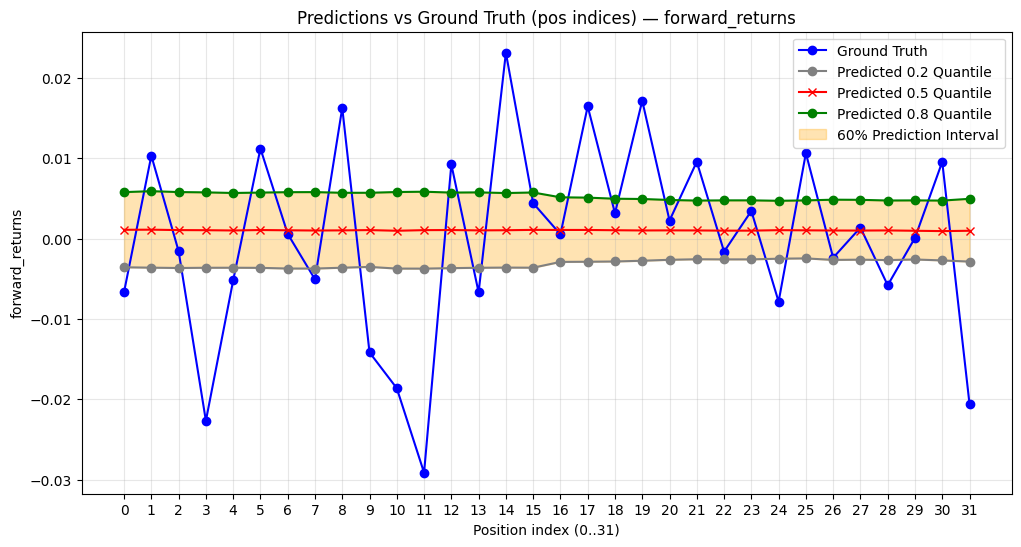

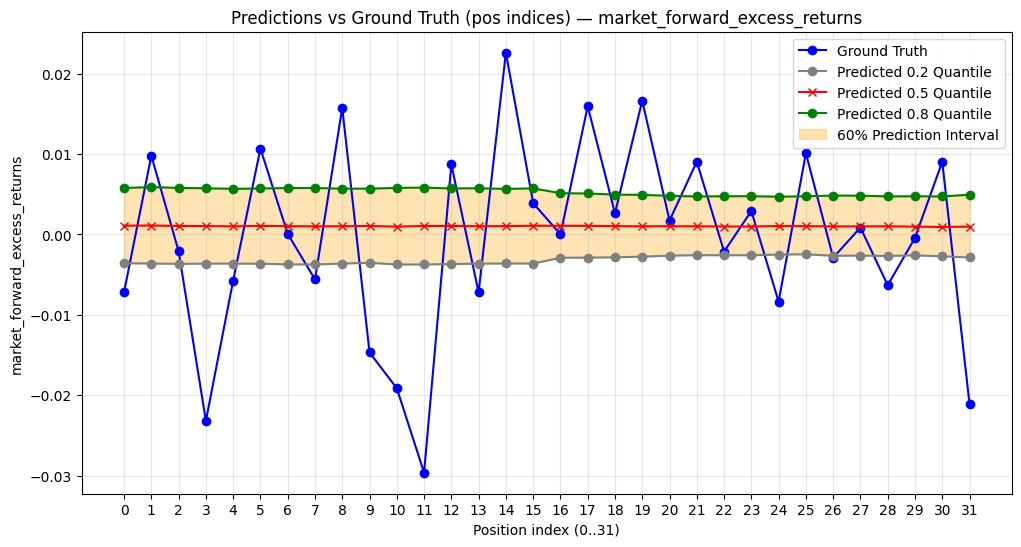

In [51]:
# Plot: align timestamps by positional index and draw quantiles
# We convert both prediction timestamps and future target timestamps to simple position indices (0..15)
# so they share the same x-axis regardless of original timestamp formats.
qcols = [f"{q:.1f}" for q in quantile_levels]
n = 32
# Take first n rows of the held-out future targets (ground truth)
future_short = future_targets.iloc[:n].copy()
# Take first n rows of predictions (should correspond to prediction_length)
pred_short = pred_df.copy().reset_index(drop=True).iloc[:n].copy()
print("future_short shape:", future_short.shape)
print("pred_short shape:", pred_short.shape)

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_short['pos'] = x
# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

# Plot each return target with median and 0.1/0.9 quantiles
for target in return_targets:

    # check quantile columns
    for q in qcols:
        if q not in pred_short.columns:
            print(f'Quantile column {q} for {target} not found in pred_df; available columns: {list(pred_short.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # Predicted quantiles
    plt.plot(x, pred_short[qcols[0]].values, label='Predicted 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_short[qcols[1]].values, label='Predicted 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_short[qcols[2]].values, label='Predicted 0.8 Quantile', color='green', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_short[qcols[0]].values, pred_short[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# fine-tune

In [47]:
import os
import sys
print(sys.path)

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import chronos as chronos
print ("Chronos version:", chronos.__version__)

from chronos.chronos2.dataset import (
    Chronos2Dataset,
    DatasetMode,
    TensorOrArray,
)

from chronos.df_utils import convert_df_input_to_list_of_dicts_input

# Prepare data for fine-tuning using the retail sales dataset
context_df = pd.read_csv("./rawData/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

# Set column names
id_column = "item_id"
timestamp_column = "date_id"
return_targets = ["forward_returns"]
quantile_levels=[0.1, 0.5, 0.9]
prediction_length = 16

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

ft_inputs, _, _ = convert_df_input_to_list_of_dicts_input(
    df=context_df,
    future_df=None,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target_columns=return_targets,
    prediction_length=prediction_length,
)

print(ft_inputs[0]["target"])  # Display the first input dictionary


['C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env', '', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env\\Lib\\site-packages', 'D:\\code-repo\\Chomo\\chronos-forecasting\\src']
Chronos version: 2.0.0
Input dataframe shape: (9021, 98)


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


[[-0.00242117 -0.00849468 -0.00962448 ...  0.00592992  0.00817256
   0.00952381]]


In [9]:
# fine-tune the Chronos-2 pipeline
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Fine-tune the model
finetuned_pipeline = pipeline.fit(
    inputs=ft_inputs,
    prediction_length=prediction_length,
    num_steps=10,  # few fine-tuning steps for a quick demo
    learning_rate=1e-5,
    batch_size=8,
    context_length= 256,
    logging_steps=2,
)

C:\Users\alex\AppData\Local\Temp\ipykernel_25160\1204246356.py:5: FutureWarning: Fine-tuning support is experimental and may be changed in future versions.
  finetuned_pipeline = pipeline.fit(
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
2,0.077800
4,0.097400
6,0.087200
8,0.071200
10,0.083600


# Uncertainty as Known Future, zero-shot

In [48]:
# Load raw data
context_df = pd.read_csv("./rawData/train.csv")

# Set column names
id_column = "item_id"
timestamp_column = "date_id"
return_targets = ["forward_returns", "market_forward_excess_returns"]
quantile_levels=[0.2, 0.5, 0.8]
prediction_length = 32

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

# Separate input and output rows
context_input = context_df[:-320] # assuming last 320 rows are to be predicted
future_targets = context_df[-320:]
print("ground truth head 5 of future_targets:")
print(future_targets.head(5))
print("\n")

# ---------------------- Step 1: predit without future covariates ------------------------------
# Make predictions
pred_df = pipeline.predict_df(
    context_input,
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=return_targets,
)
print("head 5 of pred_df:")
print(pred_df.head(5))
print("\n")

# compute the quantile bands between 0.2 and 0.8, float32
pred_df['quantile_band_0.2_0.8'] = (pred_df['0.8'] - pred_df['0.2']).astype(np.float32)

# build future_df with id column, a timestamp, and 'quantile_band_0.2_0.8'
future_df_with_band = future_targets[[id_column, timestamp_column]].copy()
future_df_with_band = future_df_with_band.reset_index(drop=True).iloc[:prediction_length]

# float32 values for quantile_band_0.2_0.8
future_df_with_band['quantile_band_0.2_0.8'] = pred_df['quantile_band_0.2_0.8'].reset_index(drop=True).iloc[:prediction_length].values
print("check type of quantile_band_0.2_0.8 column:", future_df_with_band['quantile_band_0.2_0.8'].dtype)

print("head 2 of future_df with quantile_band_0.2_0.8 column:")
print(future_df_with_band.head(2))
print("\n")

# ---------------------- Step 2: predit with future covariates ------------------------------
# Add a 'quantile_band_0.2_0.8' column to context_input, with all nan values
context_input_with_band = context_input.reset_index(drop=True).copy()
context_input_with_band['quantile_band_0.2_0.8'] = np.float32(np.nan)
print("head 2 of context_input with added quantile_band_0.2_0.8 column:")
print(context_input_with_band.head(2))
print("columns names of context_input:", context_input_with_band.columns.tolist())
print("\n")

# make predictions with future covariates
pred_df_with_future = pipeline.predict_df(
    df        = context_input_with_band,
    future_df = future_df_with_band,
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=return_targets,
)
print("head 5 of pred_df_with_future:")
print(pred_df_with_future.head(5))

ground truth head 5 of future_targets:
      date_id  D1  D2  D3  D4  D5  D6  D7  D8  D9  ...        V4        V5  \
8701     8701   0   0   0   0   0   0   0   0   0  ...  0.212302  1.093148   
8702     8702   0   0   0   0   0   0   0   0   0  ...  0.217593  1.485813   
8703     8703   0   0   0   0   0  -1   0   0   0  ...  0.216270  1.142182   
8704     8704   0   0   0   0   0  -1   0   0   0  ...  0.215608  0.675930   
8705     8705   0   0   0   0   0  -1   0   0   0  ...  0.215608  0.312397   

            V6        V7        V8        V9  forward_returns  risk_free_rate  \
8701  0.770503 -0.551740  0.028439 -0.814744        -0.006641        0.000206   
8702  0.828704 -0.478637  0.017526 -0.730719         0.010310        0.000206   
8703  0.656746 -0.679647  0.019511 -0.881521        -0.001569        0.000206   
8704  0.666667 -0.703677  0.054233 -0.893061        -0.022662        0.000205   
8705  0.848545 -0.290280  0.075397 -0.553025        -0.005210        0.000205   

     

future_short(ground truth) shape: (32, 99)
pred_without_future shape: (32, 8)
pred_with_future shape: (32, 7)
Position -> future_targets original [(0, '8701'), (1, '8702'), (2, '8703'), (3, '8704'), (4, '8705'), (5, '8706'), (6, '8707'), (7, '8708'), (8, '8709'), (9, '8710'), (10, '8711'), (11, '8712'), (12, '8713'), (13, '8714'), (14, '8715'), (15, '8716'), (16, '8717'), (17, '8718'), (18, '8719'), (19, '8720'), (20, '8721'), (21, '8722'), (22, '8723'), (23, '8724'), (24, '8725'), (25, '8726'), (26, '8727'), (27, '8728'), (28, '8729'), (29, '8730'), (30, '8731'), (31, '8732')]


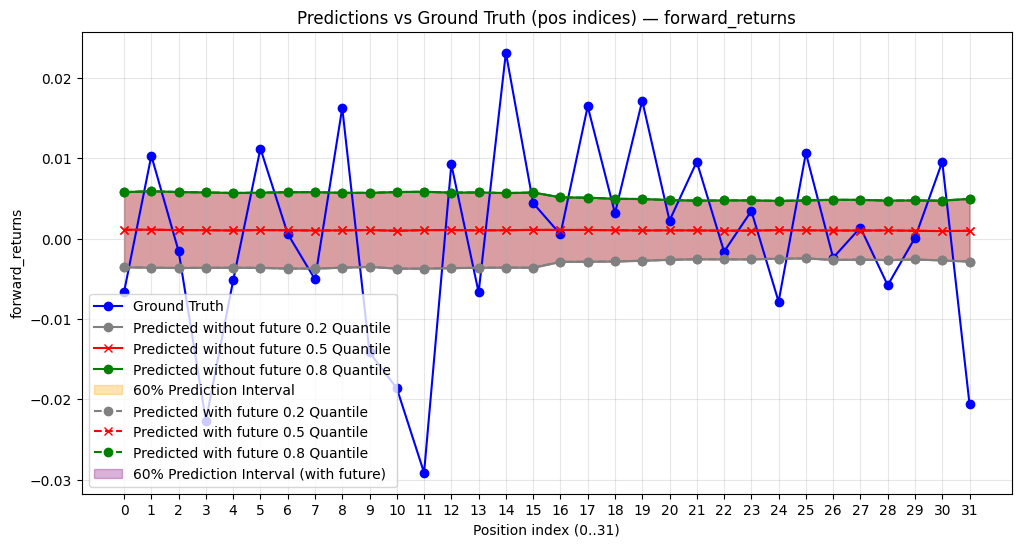

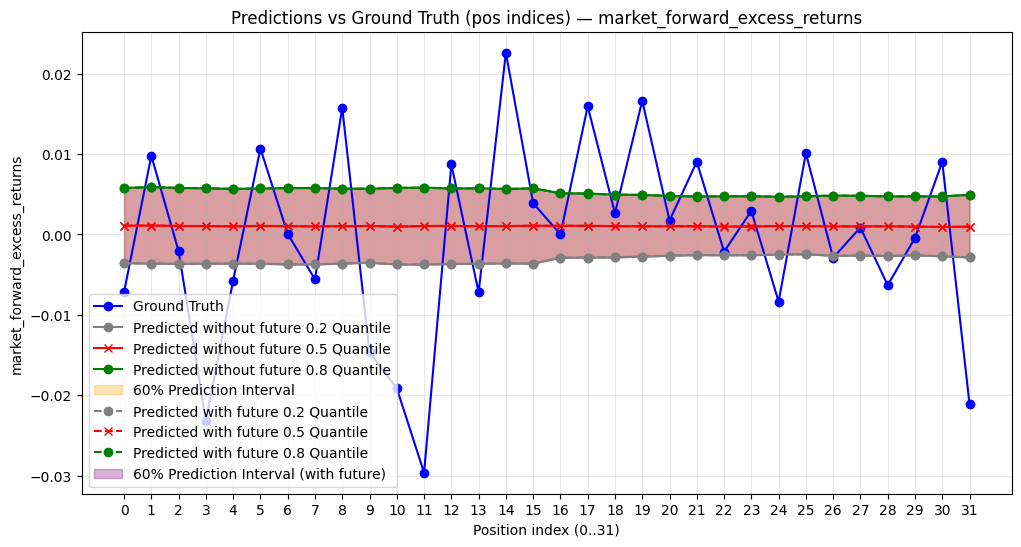

In [49]:
# ---------------------- Step 3: compare 2 prediction results ------------------------------
# plot Ground truth vs pred_df vs pred_df_with_future for a selected id
qcols = [f"{q:.1f}" for q in quantile_levels]
n = prediction_length

# Take first n rows of the held-out future targets (ground truth) and predictions
future_short = future_targets.iloc[:n].copy()
pred_without_future = pred_df.copy().reset_index(drop=True).iloc[:n].copy()
pred_with_future = pred_df_with_future.copy().reset_index(drop=True).iloc[:n].copy()
print("future_short(ground truth) shape:", future_short.shape)
print("pred_without_future shape:", pred_without_future.shape)
print("pred_with_future shape:", pred_with_future.shape)

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_without_future['pos'] = x
pred_with_future['pos'] = x

# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

# Plot each return target with median and 0.2/0.8 quantiles
for target in return_targets:
    # check quantile columns
    for q in qcols:
        if q not in pred_without_future.columns:
            print(f'Quantile column {q} for {target} not found in pred_without_future; available columns: {list(pred_without_future.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # i) Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # ii) Predicted without future quantiles
    plt.plot(x, pred_without_future[qcols[0]].values, label='Predicted without future 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_without_future[qcols[1]].values, label='Predicted without future 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_without_future[qcols[2]].values, label='Predicted without future 0.8 Quantile', color='green', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_without_future[qcols[0]].values, pred_without_future[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    # iii) Predicted with future quantiles
    plt.plot(x, pred_with_future[qcols[0]].values, label='Predicted with future 0.2 Quantile', color='gray', marker='o', linestyle='--')
    plt.plot(x, pred_with_future[qcols[1]].values, label='Predicted with future 0.5 Quantile', color='red', marker='x', linestyle='--')
    plt.plot(x, pred_with_future[qcols[2]].values, label='Predicted with future 0.8 Quantile', color='green', marker='o', linestyle='--')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_with_future[qcols[0]].values, pred_with_future[qcols[2]].values, color='purple', alpha=0.3, label='60% Prediction Interval (with future)')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()